In [ ]:
!pip install keras

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
print("Tensforflow version", tf.__version__)

Tensforflow version 2.20.0


In [ ]:
print ("GPU available", tf.config.list_physical_devices('GPU'))

GPU available [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Tensors — the data structure of deep learning

The **rank ladder**:

| Rank | Name | Shape | Example |
|---|---|---|---|
| 0 | Scalar | `()` | one temperature `36.6` |
| 1 | Vector | `(3,)` | RGB color `[255,128,0]` |
| 2 | Matrix | `(28,28)` | a grayscale image |
| 3 | 3-tensor | `(28,28,3)` | a color image |
| 4 | 4-tensor | `(32,28,28,3)` | a **batch** of 32 color images |

That last shape — `(batch, height, width, channels)` — is everywhere. The first dim is almost always the batch.

In [ ]:
s = tf.constant(36.6)
s

<tf.Tensor: shape=(), dtype=float32, numpy=36.599998474121094>

In [ ]:
v = tf.constant([255,128,0])
v

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([255, 128,   0], dtype=int32)>

In [ ]:
m = tf.constant([[1.0,2.0],
                 [3.0,4.0]])
m

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[1., 2.],
       [3., 4.]], dtype=float32)>

In [ ]:
print("shape:", m.shape, "dtype:",m.dtype, "rank:", tf.rank(m).numpy())

shape: (2, 2) dtype: <dtype: 'float32'> rank: 2


In [ ]:
x = tf.Variable(3.0)
x

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=3.0>

In [ ]:
print("zeros:\n", tf.zeros((2, 3)).numpy())
print("ones:\n",  tf.ones((2, 3)).numpy())
print("random normal:\n", tf.random.normal((2, 2)).numpy())
print("range:", tf.range(0, 10, 2).numpy())

zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
ones:
 [[1. 1. 1.]
 [1. 1. 1.]]
random normal:
 [[-1.537512  -0.8853821]
 [ 0.2842668  1.4312177]]
range: [0 2 4 6 8]


In [ ]:
arr = np.array([[1.0,2.0],
               [3.0,4.0]])
t = tf.constant(arr)
t

<tf.Tensor: shape=(2, 2), dtype=float64, numpy=
array([[1., 2.],
       [3., 4.]])>

In [ ]:
back = t.numpy()
back

array([[1., 2.],
       [3., 4.]])

## 3. Tensor operations

In [ ]:
a = tf.constant([3.0, 3.0, 3.0])
b = tf.constant([2.0, 2.0, 2.0])

print("a + b =", (a + b).numpy())
print("a - b =", (a - b).numpy())
print("a * b =", (a * b).numpy())   # ELEMENT-WISE
print("a / b =", (a / b).numpy())
print("sum:", tf.reduce_sum(a).numpy(), "| mean:", tf.reduce_mean(a).numpy())

a + b = [5. 5. 5.]
a - b = [1. 1. 1.]
a * b = [6. 6. 6.]
a / b = [1.5 1.5 1.5]
sum: 9.0 | mean: 3.0


### The two multiplications everyone confuses

In [ ]:
A = tf.constant([[1.0, 2.0], [3.0, 4.0]])
B = tf.constant([[0.5, -1.0], [1.0, 2.0]])

print("ELEMENT-WISE  A * B:\n", (A * B).numpy())     # cell-by-cell
print("\nMATRIX MULT   A @ B:\n", (A @ B).numpy())   # rows x columns

ELEMENT-WISE  A * B:
 [[ 0.5 -2. ]
 [ 3.   8. ]]

MATRIX MULT   A @ B:
 [[2.5 3. ]
 [5.5 5. ]]


In [ ]:
# Broadcasting: TF stretches the smaller shape to fit the bigger one
a = tf.constant([1, 2, 3])
print("a + 10 =", (a + 10).numpy())          # scalar stretched across the vector

M = tf.ones((3, 3))
row = tf.constant([1.0, 2.0, 3.0])
print("row added to every row of M:\n", (M + row).numpy())

a + 10 = [11 12 13]
row added to every row of M:
 [[2. 3. 4.]
 [2. 3. 4.]
 [2. 3. 4.]]


In [ ]:
inputs  = tf.constant([[1.0, 2.0], [3.0, 4.0]])   # (2 samples, 2 features)
weights = tf.constant([[0.5, -1.0], [1.0, 2.0]])  # (2 features, 2 units)
layer_output = tf.matmul(inputs, weights)          # (2 samples, 2 units)
print("Layer output:\n", layer_output.numpy())

Layer output:
 [[2.5 3. ]
 [5.5 5. ]]


## 4. Constants vs Variables — the whole game

| | `tf.constant` | `tf.Variable` |
|---|---|---|
| Mutable? | ❌ No | ✅ Yes (`.assign`) |
| Used for | input data, fixed values | **weights & biases** |
| Watched by GradientTape? | only if `tape.watch()` | ✅ automatically |

In [ ]:
a = tf.constant(5.0)     # fixed
b = tf.constant(10.0)    # fixed
x = tf.Variable(3.0)     # the "knob" we can turn

print("a*x + b =", (a * x + b).numpy())   # 5*3 + 10 = 25

x.assign(4.0)                              # turn the dial
print("after x.assign(4.0):", (a * x + b).numpy())   # 5*4 + 10 = 30

a*x + b = 25.0
after x.assign(4.0): 30.0


## 5. Automatic differentiation — `GradientTape`
**Analogy:** a tape recorder that records your math, then rewinds and applies the chain rule for free.

In [ ]:
x = tf.Variable(3.0)

with tf.GradientTape() as tape:
    y = x**2 + 2*x - 5          # y = x² + 2x − 5

dy_dx = tape.gradient(y, x)     # derivative is 2x + 2  ->  at x=3 -> 8
print("dy/dx at x=3:", dy_dx.numpy())   # 8.0  (check by hand: 2*3+2 = 8)

dy/dx at x=3: 8.0


### A mini training step by hand (this IS deep learning)


In [ ]:
# Toy linear model  y_pred = w*x + b, fit to y_true = 10
w = tf.Variable(1.0)
b = tf.Variable(0.0)
x = tf.constant(2.0)
y_true = tf.constant(20.0)
lr = 0.01

for step in range(50):
    with tf.GradientTape() as tape:
        y_pred = w * x + b
        loss = (y_pred - y_true) ** 2          # squared error

    grad_w, grad_b = tape.gradient(loss, [w, b])   # gradients for BOTH at once
    w.assign_sub(lr * grad_w)                       # gradient descent step
    b.assign_sub(lr * grad_b)

print(f"Learned w={w.numpy():.2f}, b={b.numpy():.2f}, final loss={loss.numpy():.4f}")

Learned w=8.16, b=3.58, final loss=0.0106


## 6. From a hand-built neuron to Keras

We'll classify Iris — is it *setosa* (1) or not (0)?

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


class Perceptron:
    """A single neuron with a step activation — the simplest neural net."""
    def __init__(self, learning_rate=0.1, epochs=10):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def _activation(self, z):
        return 1 if z >= 0 else 0          # step: fire if weighted sum crosses 0

    def predict(self, inputs):
        return self._activation(np.dot(inputs, self.weights) + self.bias)

    def fit(self, X, y):
        self.weights = np.random.rand(X.shape[1])   # one weight per feature
        self.bias = np.random.rand(1)
        for _ in range(self.epochs):
            for inputs, target in zip(X, y):
                error = target - self.predict(inputs)   # +1, 0, or -1
                # perceptron learning rule = hand-written gradient descent
                self.weights += self.learning_rate * error * inputs
                self.bias    += self.learning_rate * error


iris = load_iris()
# print(iris)
X = iris.data[:, :2]
# print(X)                       # first two features
y = np.where(iris.target != 0, 0, 1)        # setosa=1, else=0 (linearly separable)
# print(y)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0)

clf = Perceptron(learning_rate=0.1, epochs=10)
clf.fit(X_tr, y_tr)
y_pred = np.array([clf.predict(x) for x in X_te])
print(classification_report(y_te, y_pred, target_names=["Iris-other", "Iris-setosa"]))

              precision    recall  f1-score   support

  Iris-other       1.00      1.00      1.00        19
 Iris-setosa       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
def sigmoid(x): return 1 / (1 + np.exp(-x))   # squashes to (0, 1)
def relu(x):    return np.maximum(0, x)         # keeps positives, zeros negatives
def tanh(x):    return np.tanh(x)               # squashes to (-1, 1)

x = np.array([-1.0, 0.0, 1.0, 2.0])
print("Sigmoid:", sigmoid(x))
print("ReLU:   ", relu(x))
print("Tanh:   ", tanh(x))

Sigmoid: [0.26894142 0.5        0.73105858 0.88079708]
ReLU:    [0. 0. 1. 2.]
Tanh:    [-0.76159416  0.          0.76159416  0.96402758]


## 7. Your first Keras network — the Sequential API

Use **Sequential** when the model is a straight pipe: input → layer → layer → output.

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(2,)),                 # 2 input features (modern way!)
    layers.Dense(8, activation="relu"),      # hidden layer
    layers.Dense(1, activation="sigmoid"),   # output: probability of class 1
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

### Functional API (brief) — for anything that branches

Use it when your model has branches, merges, or multiple inputs/outputs — things Sequential can't express. Read it like plumbing: each layer is a function you call on the previous tensor.

In [ ]:
inputs  = keras.Input(shape=(2,))
x       = layers.Dense(8, activation="relu")(inputs)
outputs = layers.Dense(1, activation="sigmoid")(x)

functional_model = keras.Model(inputs=inputs, outputs=outputs)
functional_model.summary()
# Same model as above — Sequential is just a special case of Functional.

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

## 8. The core workflow: build → COMPILE → FIT → EVALUATE → PREDICT

We'll now do the real thing on **Fashion-MNIST**: 28×28 grayscale clothing images, 10 classes. This is the capstone of the module and the full deep-learning lifecycle.


In [ ]:
tf.random.set_seed(42)   # reproducibility

fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Train:", train_images.shape, "| Test:", test_images.shape)

Train: (60000, 28, 28) | Test: (10000, 28, 28)


### Step 1 — Explore & preprocess (NORMALIZE!)

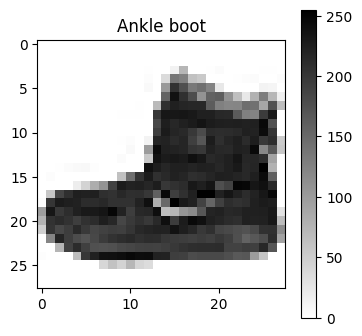

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(train_images[0], cmap="binary")
plt.title(class_names[train_labels[0]]); plt.colorbar();
plt.show()

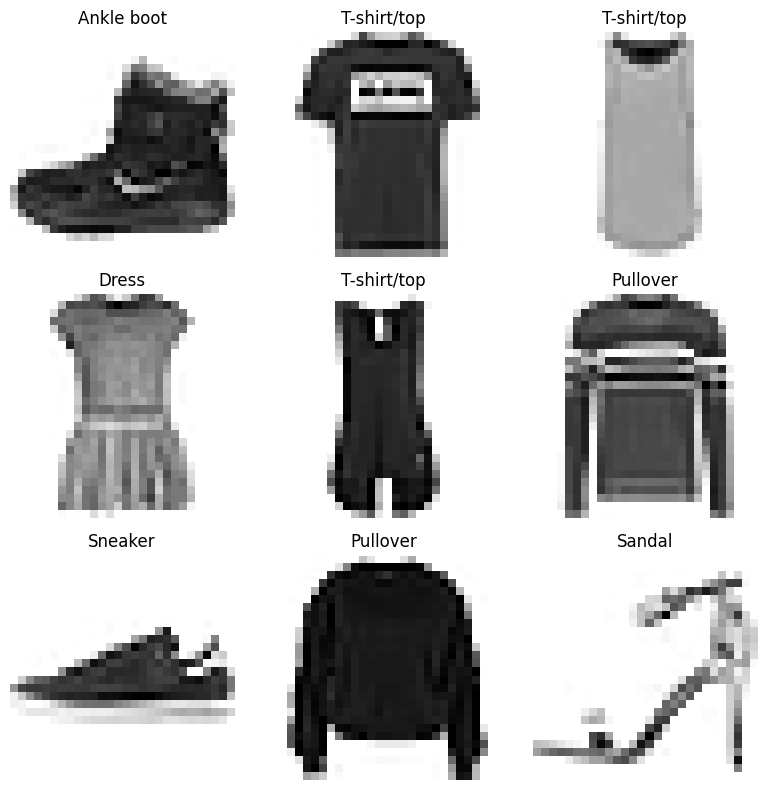

In [ ]:
# Normalize both sets identically
train_images = train_images / 255.0
test_images  = test_images  / 255.0

# Show 9 samples to confirm the data looks right
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(train_images[i], cmap="binary")
    plt.title(class_names[train_labels[i]]); plt.axis("off")
plt.tight_layout(); plt.show()

### Step 2 — Build the model

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    layers.Flatten(),                        # 28x28 -> 784-vector
    layers.Dense(128, activation="relu"),
    layers.Dense(10),                        # raw logits (no softmax here)
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3 — Compile: tell the model HOW to learn

- **optimizer** — how to update weights (`adam` is the sensible default)
- **loss** — the number to minimize (pick by task!)
- **metrics** — extra numbers for humans to read

| Task | Output layer | Loss |
|---|---|---|
| Binary | `Dense(1,'sigmoid')` | `binary_crossentropy` |
| Multi-class, integer labels | `Dense(C,'softmax')` | `sparse_categorical_crossentropy` |
| Multi-class, one-hot labels | `Dense(C,'softmax')` | `categorical_crossentropy` |
| Regression | `Dense(1,'linear')` | `mean_squared_error` |

In [ ]:
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
print("Compiled. Ready to train.")

Compiled. Ready to train.



### Step 4 — Train (with validation + EarlyStopping)

`EarlyStopping` watches validation loss and stops when it stops improving, restoring the best weights.

In [ ]:
callbacks = [keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]

history = model.fit(
    train_images, train_labels,
    epochs=20,
    validation_split=0.1,     # hold out 10% of TRAIN for validation
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8230 - loss: 0.5040 - val_accuracy: 0.8482 - val_loss: 0.4134
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8632 - loss: 0.3793 - val_accuracy: 0.8645 - val_loss: 0.3713
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8758 - loss: 0.3395 - val_accuracy: 0.8675 - val_loss: 0.3599
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8849 - loss: 0.3142 - val_accuracy: 0.8697 - val_loss: 0.3677
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8926 - loss: 0.2941 - val_accuracy: 0.8737 - val_loss: 0.3544
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8968 - loss: 0.2781 - val_accuracy: 0.8732 - val_loss: 0.3667
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9013 - loss: 0.2649 - val_accuracy: 0.8737 - val_loss: 0.3671
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9052 - loss: 0.2536 - 

### Reading the curves — spotting overfitting live

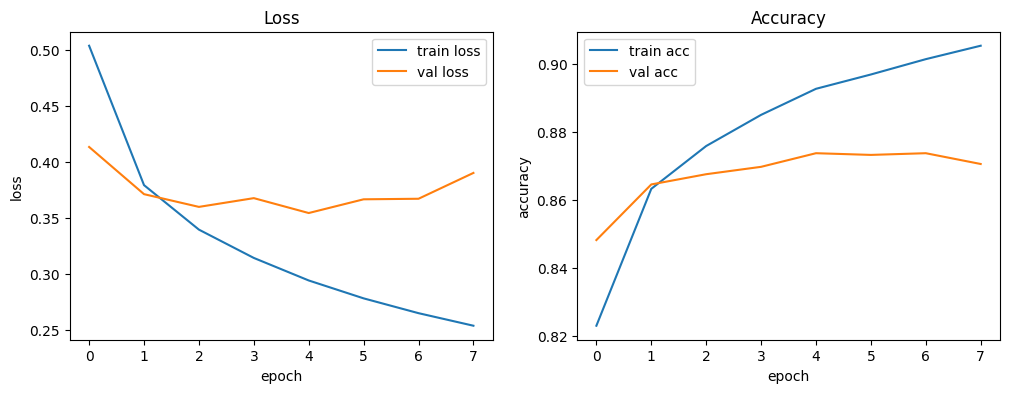

In [ ]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history["loss"], label="train loss")
    if "val_loss" in history.history:
        ax1.plot(history.history["val_loss"], label="val loss")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.set_title("Loss")

    ax2.plot(history.history["accuracy"], label="train acc")
    if "val_accuracy" in history.history:
        ax2.plot(history.history["val_accuracy"], label="val acc")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend(); ax2.set_title("Accuracy")
    plt.show()

plot_history(history)

### Step 5 — Evaluate on the untouched test set

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nTest accuracy: {test_acc:.3f}")   # ~0.88 is typical

313/313 - 1s - 2ms/step - accuracy: 0.8665 - loss: 0.3822

Test accuracy: 0.867


### Step 6 — Predict on new data

Since our model outputs logits, we attach a Softmax layer to read probabilities.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


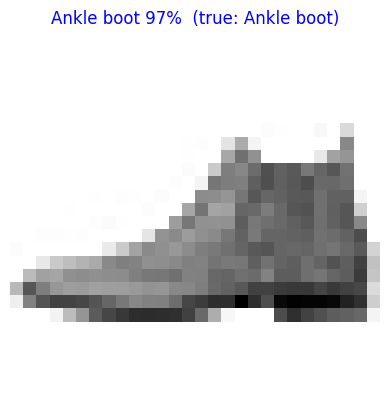

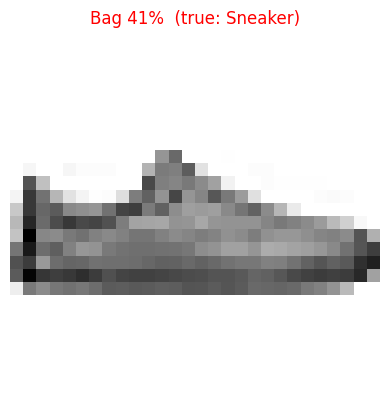

In [ ]:
# Attach softmax so outputs are readable probabilities
probability_model = keras.Sequential([model, layers.Softmax()])
predictions = probability_model.predict(test_images)

def show_prediction(i):
    probs = predictions[i]
    guess, truth = np.argmax(probs), test_labels[i]
    color = "blue" if guess == truth else "red"
    plt.imshow(test_images[i], cmap="binary")
    plt.title(f"{class_names[guess]} {100*probs.max():.0f}%  (true: {class_names[truth]})",
              color=color)
    plt.axis("off"); plt.show()

show_prediction(0)
show_prediction(12)

In [ ]:
# Predicting on a SINGLE image the right way (note the batch dimension)
single = test_images[0]                        # shape (28, 28)
single_batch = np.expand_dims(single, axis=0)  # shape (1, 28, 28)  <- the fix
probs = probability_model.predict(single_batch)
print("Predicted class:", np.argmax(probs[0]),
      "| name:", class_names[np.argmax(probs[0])],
      "| confidence:", f"{probs[0].max():.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
Predicted class: 9 | name: Ankle boot | confidence: 0.97


### Step 7 — Save & reload (prove it persists)


In [ ]:
model.save("fashion_mnist.keras")                          # architecture + weights + optimizer
reloaded = keras.models.load_model("fashion_mnist.keras")  # no need to rebuild
loss2, acc2 = reloaded.evaluate(test_images, test_labels, verbose=0)
print(f"Reloaded model accuracy: {acc2:.3f}  (matches the original)")

Reloaded model accuracy: 0.867  (matches the original)
